# Notebook 07 - Visualisation finale corrig?e

Nous rassemblons les r?sultats finaux apr?s filtrage fort, red?tection locale et lissage de la trajectoire.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import load_image, load_image_sequence
from src.trajectory import load_trajectory_csv, compute_groundtruth_centers, compare_trajectory_with_groundtruth

Racine du projet: C:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## Champ de mouvement

Nous avons utilis? Lucas-Kanade pour estimer le d?placement des points caract?ristiques de la voiture. Les vecteurs obtenus forment un champ de mouvement sparse.

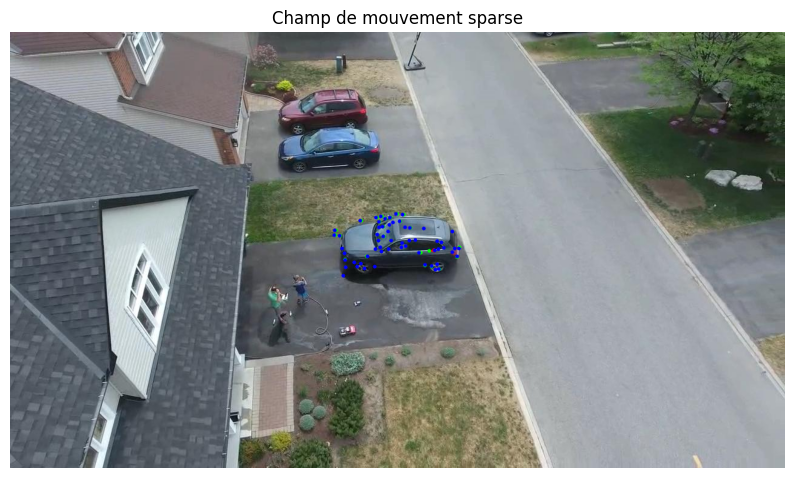

In [2]:
motion_field_path = FRAMES_DIR / "motion_field_frame.png"
if motion_field_path.exists():
    motion_field = cv2.imread(str(motion_field_path))
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(motion_field, cv2.COLOR_BGR2RGB))
    plt.title("Champ de mouvement sparse")
    plt.axis("off")
    plt.show()
else:
    print("Executez d'abord le notebook 04 pour g?n?rer motion_field_frame.png")

Nous observons un champ sparse : les vecteurs sont calcul?s seulement sur les points caract?ristiques suivis.

## Trajectoire globale liss?e

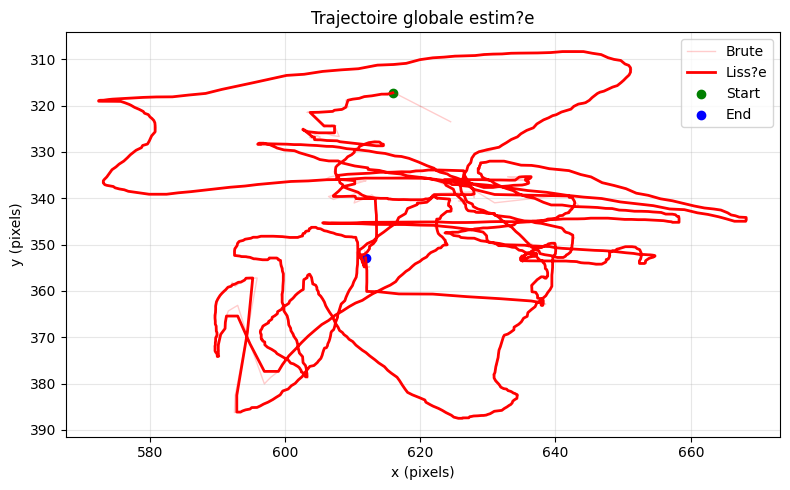

In [3]:
trajectory_df = load_trajectory_csv(RESULTS_DIR / "trajectory_estimated.csv")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(trajectory_df["center_x"], trajectory_df["center_y"], color="red", alpha=0.20, linewidth=1, label="Brute")
ax.plot(trajectory_df["center_x_smooth"], trajectory_df["center_y_smooth"], color="red", linewidth=2, label="Liss?e")
ax.scatter(trajectory_df["center_x_smooth"].iloc[0], trajectory_df["center_y_smooth"].iloc[0], color="green", label="Start")
ax.scatter(trajectory_df["center_x_smooth"].iloc[-1], trajectory_df["center_y_smooth"].iloc[-1], color="blue", label="End")
ax.set_title("Trajectoire globale estim?e")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "trajectory_2d.png", dpi=150, bbox_inches="tight")
plt.show()

Nous avons calcul? le centre robuste de l'objet ? chaque frame, puis nous avons liss? cette trajectoire avec une m?diane glissante.

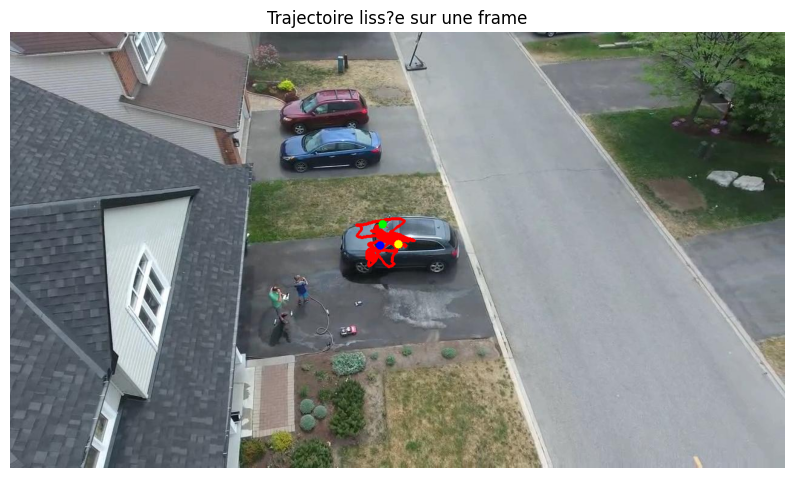

In [4]:
image_paths = load_image_sequence(IMG_DIR)
frame = load_image(image_paths[0]).copy()
points = trajectory_df[["center_x_smooth", "center_y_smooth"]].dropna().to_numpy(dtype=np.int32)
raw_points = trajectory_df[["center_x", "center_y"]].dropna().to_numpy(dtype=np.int32)

if len(raw_points) >= 2:
    cv2.polylines(frame, [raw_points.reshape(-1, 1, 2)], False, (0, 0, 255), 1)
if len(points) >= 2:
    cv2.polylines(frame, [points.reshape(-1, 1, 2)], False, (0, 0, 255), 3)

if len(points) > 0:
    start = tuple(points[0])
    current = tuple(points[len(points) // 2])
    end = tuple(points[-1])
    cv2.circle(frame, start, 7, (0, 255, 0), -1)
    cv2.circle(frame, current, 7, (0, 255, 255), -1)
    cv2.circle(frame, end, 7, (255, 0, 0), -1)

cv2.imwrite(str(FRAMES_DIR / "trajectory_on_frame.png"), frame)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Trajectoire liss?e sur une frame")
plt.axis("off")
plt.show()

Nous observons la trajectoire sur une frame. Start est en vert, Current en jaune et End en bleu.

## Vitesse et direction

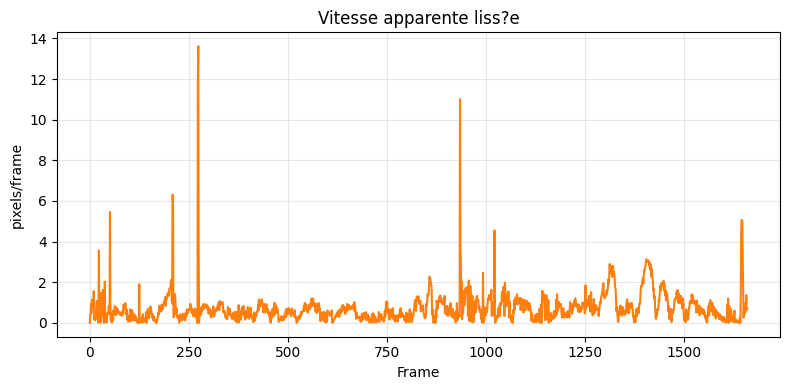

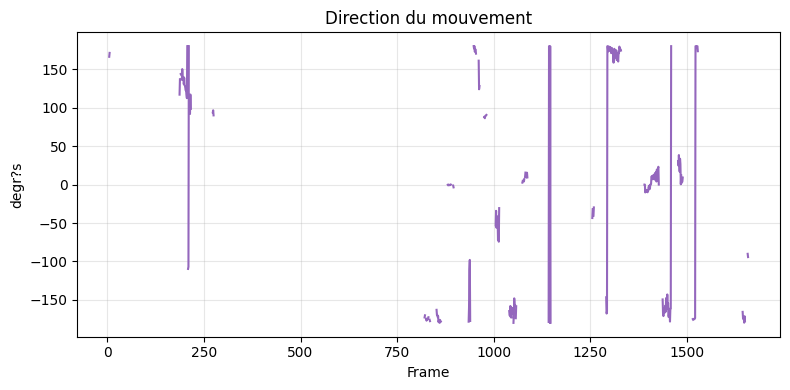

In [5]:
motion_df = pd.read_csv(RESULTS_DIR / "motion_analysis_estimated.csv")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(motion_df["frame_id"], motion_df["speed_px_frame"], color="tab:orange")
ax.set_title("Vitesse apparente liss?e")
ax.set_xlabel("Frame")
ax.set_ylabel("pixels/frame")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "speed_curve.png", dpi=150, bbox_inches="tight")
plt.show()

direction_for_plot = motion_df["direction_deg"].where(motion_df["speed_px_frame"] >= 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(motion_df["frame_id"], direction_for_plot, color="tab:purple")
ax.set_title("Direction du mouvement")
ax.set_xlabel("Frame")
ax.set_ylabel("degr?s")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "direction_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Nous avons calcul? `dx`, `dy`, la distance, la vitesse apparente en pixels/frame et la direction avec `atan2` ? partir de la trajectoire liss?e.

## Comparaison avec groundtruth

Erreur moyenne: 20.31 px
Erreur maximale: 43.49 px


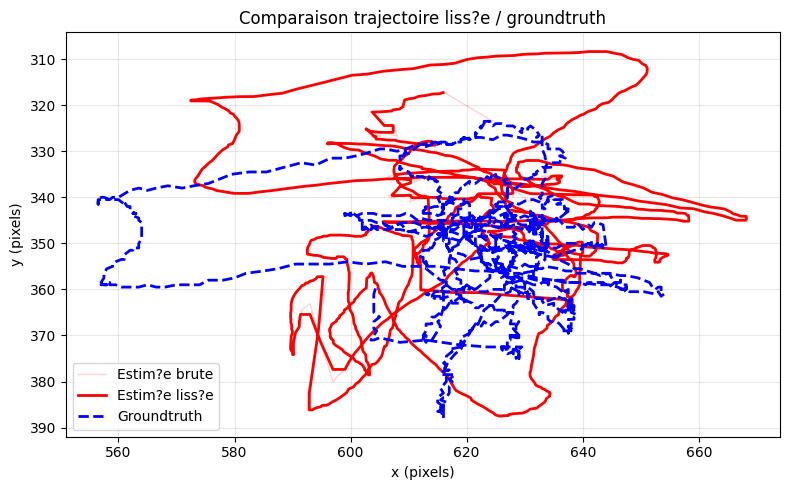

In [6]:
gt_df = compute_groundtruth_centers(DATA_DIR / "groundtruth.txt")
comparison_df = compare_trajectory_with_groundtruth(trajectory_df, gt_df)
print(f"Erreur moyenne: {comparison_df['error_px'].mean():.2f} px")
print(f"Erreur maximale: {comparison_df['error_px'].max():.2f} px")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(trajectory_df["center_x"], trajectory_df["center_y"], color="red", alpha=0.18, linewidth=1, label="Estim?e brute")
ax.plot(trajectory_df["center_x_smooth"], trajectory_df["center_y_smooth"], color="red", linewidth=2, label="Estim?e liss?e")
ax.plot(gt_df["center_x"], gt_df["center_y"], color="blue", linestyle="--", linewidth=2, label="Groundtruth")
ax.set_title("Comparaison trajectoire liss?e / groundtruth")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "comparison_groundtruth.png", dpi=150, bbox_inches="tight")
plt.show()

Nous interpr?tons cette comparaison comme une ?valuation finale. Le groundtruth n'est jamais utilis? pour corriger le suivi.

## Conclusion finale

1. Nous avons estim? le champ de mouvement avec Lucas-Kanade.
2. Nous avons extrait une trajectoire globale plus stable avec filtrage fort, red?tection locale et centre robuste.
3. Nous avons analys? la vitesse et la direction ? partir des d?placements du centre liss?.

La voiture reste consid?r?e comme un objet rigide. Lucas-Kanade fonctionne mieux avec de petits d?placements et une illumination presque constante.